In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
import os
from dotenv import load_dotenv

load_dotenv()

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:

def get_conn():
    return snowflake.connector.connect(
        account   = os.getenv("SNOWFLAKE_ACCOUNT"),
        user      = os.getenv("SNOWFLAKE_USER"),
        password  = os.getenv("SNOWFLAKE_PASSWORD"),
        database  = "ANALYTICS_DEV",
        schema    = "MARTS",
        warehouse = os.getenv("SNOWFLAKE_WAREHOUSE"),
        role      = os.getenv("SNOWFLAKE_ROLE")
    )

def query(sql):
    conn = get_conn()
    df = pd.read_sql(sql, conn)
    conn.close()
    df.columns = [c.lower() for c in df.columns]
    return df

print("Connection ready")

Connection ready


In [3]:

cohort_query = """
with user_cohorts as (
    select
        user_id,
        date_trunc('month', min(order_date))    as cohort_month,
        min(order_date)                          as first_order_date
    from analytics_dev.marts.fct_orders
    group by user_id
),
user_orders as (
    select
        o.user_id,
        o.order_date,
        c.cohort_month,
        datediff('week', c.first_order_date, o.order_date) as weeks_since_first
    from analytics_dev.marts.fct_orders o
    join user_cohorts c on o.user_id = c.user_id
    where datediff('week', c.first_order_date, o.order_date) > 0
),
cohort_size as (
    select
        cohort_month,
        count(distinct user_id) as total_users
    from user_cohorts
    group by cohort_month
),
retention as (
    select
        uo.cohort_month,
        uo.weeks_since_first,
        count(distinct uo.user_id) as retained_users
    from user_orders uo
    where uo.weeks_since_first <= 12
    group by uo.cohort_month, uo.weeks_since_first
)
select
    r.cohort_month,
    r.weeks_since_first,
    r.retained_users,
    cs.total_users,
    round(r.retained_users * 100.0 / cs.total_users, 2) as retention_pct
from retention r
join cohort_size cs on r.cohort_month = cs.cohort_month
order by r.cohort_month, r.weeks_since_first
"""

cohort_df = query(cohort_query)
print(cohort_df.shape)
cohort_df.head(10)

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/3535373513.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


(12, 5)


,cohort_month,weeks_since_first,retained_users,total_users,retention_pct
0,2024-01-01,1,84933,206209,41.19
1,2024-01-01,2,84764,206209,41.11
2,2024-01-01,3,81949,206209,39.74
3,2024-01-01,4,123700,206209,59.99
4,2024-01-01,5,85889,206209,41.65
5,2024-01-01,6,85847,206209,41.63
6,2024-01-01,7,83085,206209,40.29
7,2024-01-01,8,99623,206209,48.31
8,2024-01-01,9,78851,206209,38.24
9,2024-01-01,10,78778,206209,38.20


The spike at week 4 (59.99%) is interesting and makes sense — monthly shoppers coming back exactly 4 weeks later.

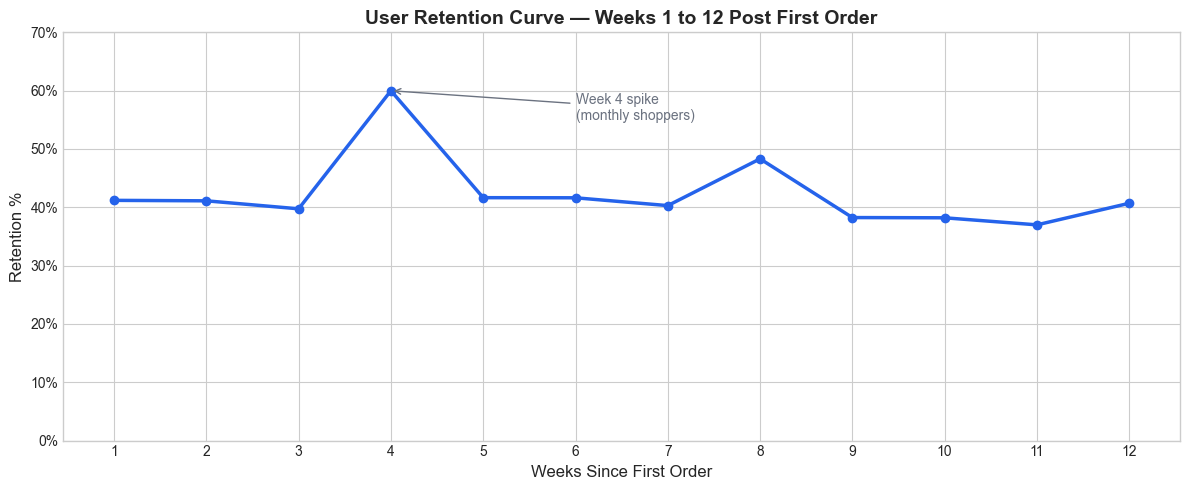

Saved to docs/retention_curve.png


In [4]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    cohort_df['weeks_since_first'],
    cohort_df['retention_pct'],
    marker='o', linewidth=2.5, markersize=6, color='#2563EB'
)

# Highlight week 4 spike
week4 = cohort_df[cohort_df['weeks_since_first'] == 4]
ax.annotate(
    'Week 4 spike\n(monthly shoppers)',
    xy=(4, week4['retention_pct'].values[0]),
    xytext=(6, 55),
    arrowprops=dict(arrowstyle='->', color='#6B7280'),
    fontsize=10, color='#6B7280'
)

ax.set_xlabel('Weeks Since First Order', fontsize=12)
ax.set_ylabel('Retention %', fontsize=12)
ax.set_title('User Retention Curve — Weeks 1 to 12 Post First Order', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 70)

plt.tight_layout()
plt.savefig('../docs/retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/retention_curve.png")

In [5]:
d7 = cohort_df[cohort_df['weeks_since_first'] == 1]['retention_pct'].values[0]
d14 = cohort_df[cohort_df['weeks_since_first'] == 2]['retention_pct'].values[0]
d30 = cohort_df[cohort_df['weeks_since_first'] == 4]['retention_pct'].values[0]

print(f"Week 1 (D7) Retention:  {d7:.1f}%")
print(f"Week 2 (D14) Retention: {d14:.1f}%")
print(f"Week 4 (D30) Retention: {d30:.1f}%")
print(f"\nWeek 4 lift over Week 1: {((d30/d7)-1)*100:.1f}% higher")

Week 1 (D7) Retention:  41.2%
Week 2 (D14) Retention: 41.1%
Week 4 (D30) Retention: 60.0%

Week 4 lift over Week 1: 45.6% higher


## Insight 1: Retention Curve & Activation Window

**Finding:** Retention stabilises between 38–42% for weeks 1–3, 
then spikes to ~60% at week 4 — driven by monthly shopping behaviour.

**Implication for product:**
- The **activation window is weeks 1–2** — users who don't reorder 
  in the first 14 days are unlikely to become weekly shoppers
- Week 4 spike confirms a strong **monthly shopper segment** — 
  a distinct persona from weekly power users
- **Onboarding nudges should fire at day 5–6** (before the week 1 
  drop-off) to pull users back into a weekly habit
- Consider a **"your weekly basket" reminder** at day 6 post first order 
  targeting users who haven't reordered yet

In [6]:

dept_query = """
select
    p.department,
    count(op.order_id)                                          as total_orders,
    sum(case when op.is_reordered then 1 else 0 end)           as reordered_items,
    round(sum(case when op.is_reordered then 1 else 0 end) * 100.0 
          / nullif(count(op.order_id), 0), 2)                  as reorder_rate_pct,
    round(avg(op.add_to_cart_order), 2)                        as avg_cart_position
from analytics_dev.marts.fct_order_products op
join analytics_dev.marts.dim_products p
    on op.product_id = p.product_id
group by p.department
order by reorder_rate_pct desc
"""

dept_df = query(dept_query)
print(dept_df.shape)
dept_df

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/3535373513.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


(21, 5)


,department,total_orders,reordered_items,reorder_rate_pct,avg_cart_position
0,dairy eggs,5631067,3773723,67.02,7.51
1,beverages,2804175,1832952,65.37,6.98
2,produce,9888378,6432596,65.05,8.04
3,bakery,1225181,769880,62.84,8.10
4,deli,1095540,666231,60.81,8.71
5,pets,102221,61594,60.26,7.73
6,babies,438743,253453,57.77,10.60
7,bulk,35932,20736,57.71,8.42
8,snacks,3006412,1727075,57.45,9.20
9,alcohol,159294,90992,57.12,5.44


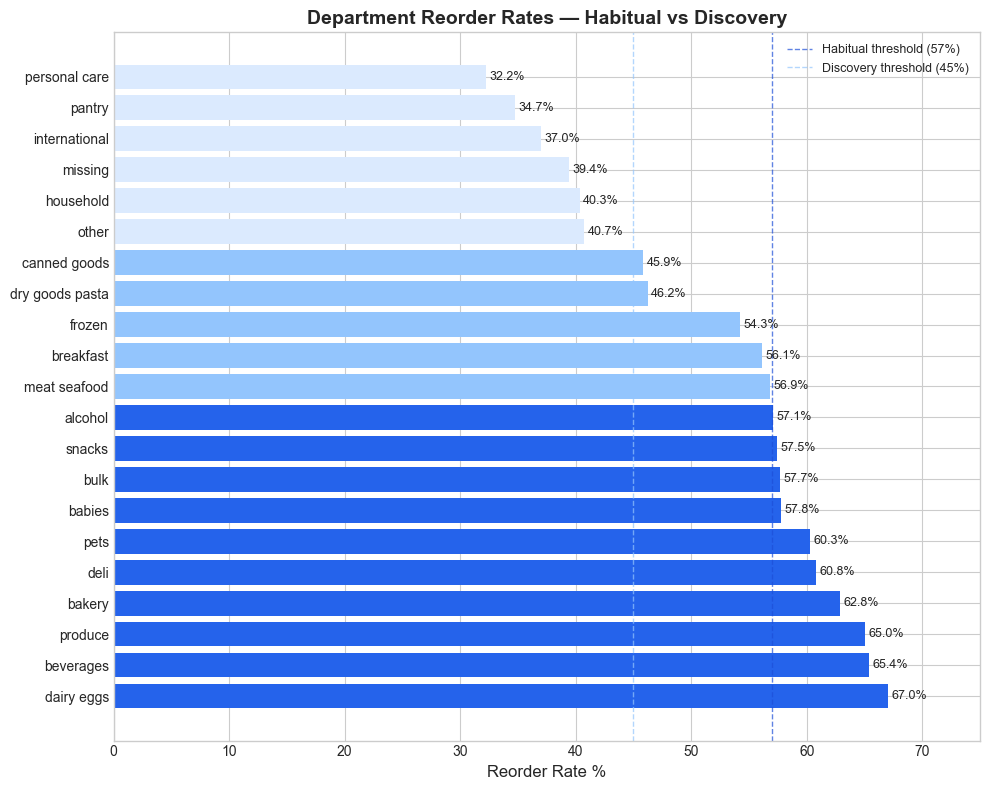

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2563EB' if x >= 57 else '#93C5FD' if x >= 45 else '#DBEAFE' 
          for x in dept_df['reorder_rate_pct']]

bars = ax.barh(dept_df['department'], dept_df['reorder_rate_pct'], color=colors)

# Add value labels
for bar, val in zip(bars, dept_df['reorder_rate_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# Threshold lines
ax.axvline(x=57, color='#1D4ED8', linestyle='--', linewidth=1, alpha=0.7, label='Habitual threshold (57%)')
ax.axvline(x=45, color='#93C5FD', linestyle='--', linewidth=1, alpha=0.7, label='Discovery threshold (45%)')

ax.set_xlabel('Reorder Rate %', fontsize=12)
ax.set_title('Department Reorder Rates — Habitual vs Discovery', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 75)

plt.tight_layout()
plt.savefig('../docs/dept_reorder_rates.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/1018549681.py:39: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/1018549681.py:40: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig('../docs/dept_scatter.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/dbtenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


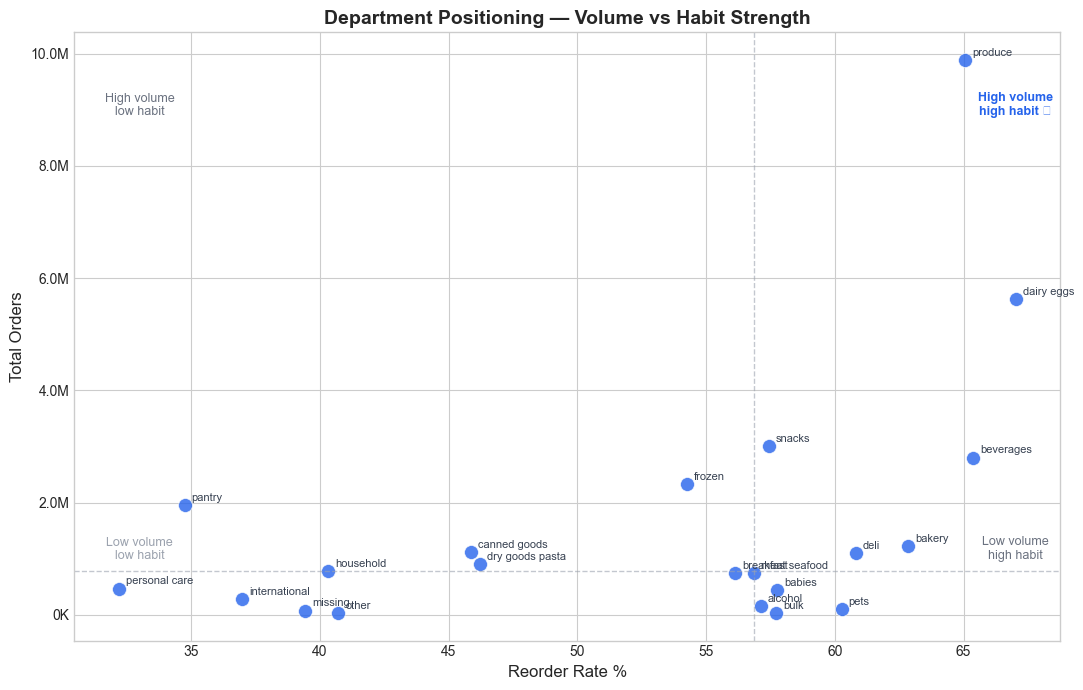

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    dept_df['reorder_rate_pct'],
    dept_df['total_orders'],
    s=100, alpha=0.8, color='#2563EB', edgecolors='white', linewidth=0.5
)

# Label each point
for _, row in dept_df.iterrows():
    ax.annotate(
        row['department'],
        xy=(row['reorder_rate_pct'], row['total_orders']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=8, color='#374151'
    )

# Quadrant lines
median_reorder = dept_df['reorder_rate_pct'].median()
median_orders = dept_df['total_orders'].median()
ax.axvline(x=median_reorder, color='#9CA3AF', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=median_orders, color='#9CA3AF', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
ax.text(33, dept_df['total_orders'].max() * 0.9, 'High volume\nlow habit', 
        fontsize=9, color='#6B7280', ha='center')
ax.text(67, dept_df['total_orders'].max() * 0.9, 'High volume\nhigh habit ⭐', 
        fontsize=9, color='#2563EB', ha='center', fontweight='bold')
ax.text(33, dept_df['total_orders'].max() * 0.1, 'Low volume\nlow habit', 
        fontsize=9, color='#9CA3AF', ha='center')
ax.text(67, dept_df['total_orders'].max() * 0.1, 'Low volume\nhigh habit', 
        fontsize=9, color='#6B7280', ha='center')

ax.set_xlabel('Reorder Rate %', fontsize=12)
ax.set_ylabel('Total Orders', fontsize=12)
ax.set_title('Department Positioning — Volume vs Habit Strength', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('../docs/dept_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Key numbers for the insight
habitual = dept_df[dept_df['reorder_rate_pct'] >= 57]['department'].tolist()
discovery = dept_df[dept_df['reorder_rate_pct'] < 45]['department'].tolist()

print(f"Habitual departments (57%+ reorder): {habitual}")
print(f"Discovery departments (<45% reorder): {discovery}")
print(f"\nHighest reorder: {dept_df.iloc[0]['department']} at {dept_df.iloc[0]['reorder_rate_pct']}%")
print(f"Lowest reorder: {dept_df.iloc[-1]['department']} at {dept_df.iloc[-1]['reorder_rate_pct']}%")
print(f"Gap between highest and lowest: {dept_df.iloc[0]['reorder_rate_pct'] - dept_df.iloc[-1]['reorder_rate_pct']:.1f}pp")

Habitual departments (57%+ reorder): ['dairy eggs', 'beverages', 'produce', 'bakery', 'deli', 'pets', 'babies', 'bulk', 'snacks', 'alcohol']
Discovery departments (<45% reorder): ['other', 'household', 'missing', 'international', 'pantry', 'personal care']

Highest reorder: dairy eggs at 67.02%
Lowest reorder: personal care at 32.19%
Gap between highest and lowest: 34.8pp


## 🔍 Insight 2: Habitual vs Discovery Departments

**Finding:** A 35 percentage point gap exists between the most habitual 
(dairy eggs 67%) and most discovery-driven (personal care 32%) departments.

**Three distinct behavioural segments emerge:**

- **Subscription-like staples** (57%+): dairy eggs, beverages, produce, 
  bakery, deli — users reorder these on autopilot. These anchor the basket.
  
- **Considered repurchases** (45–57%): pets, babies, snacks, alcohol, 
  meat seafood — users buy again but with more deliberation.

- **Discovery purchases** (<45%): dry goods, canned goods, international, 
  pantry, personal care — users explore and experiment here.

**Implication for product:**
- **Recommendation engine** should lead with habitual items to reduce 
  friction and increase basket completion rate
- **Discovery departments** are where new product launches and promotions 
  drive the most incremental revenue — users are open to trying new things
- **Produce + dairy** in the top-right quadrant (high volume + high habit) 
  are the most critical categories to protect — losing a user here means 
  losing the whole basket

In [10]:
# Pull user order data
power_query = """
with user_stats as (
    select
        user_id,
        count(order_id)                         as total_orders,
        min(order_date)                         as first_order_date,
        max(order_date)                         as last_order_date,
        avg(total_products_in_order)            as avg_basket_size,
        avg(days_since_prior_order)             as avg_days_between_orders,
        avg(reorder_rate_in_order)              as avg_reorder_rate
    from analytics_dev.marts.fct_orders
    group by user_id
),
deciles as (
    select
        *,
        ntile(10) over (order by total_orders desc) as order_decile
    from user_stats
)
select
    order_decile,
    count(user_id)                              as user_count,
    sum(total_orders)                           as total_orders,
    round(avg(total_orders), 1)                 as avg_orders,
    round(avg(avg_basket_size), 2)              as avg_basket_size,
    round(avg(avg_days_between_orders), 1)      as avg_days_between_orders,
    round(avg(avg_reorder_rate) * 100, 2)       as avg_reorder_rate_pct
from deciles
group by order_decile
order by order_decile
"""

power_df = query(power_query)
print(power_df.shape)
power_df

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/3535373513.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


(10, 7)


,order_decile,user_count,total_orders,avg_orders,avg_basket_size,avg_days_between_orders,avg_reorder_rate_pct
0,1,20621,1183855,57.4,10.27,6.4,73.02
1,2,20621,614595,29.8,10.35,10.1,64.65
2,3,20621,420416,20.4,10.22,12.7,58.52
3,4,20621,311579,15.1,10.08,14.6,53.08
4,5,20621,241264,11.7,10.01,16.1,48.22
5,6,20621,190404,9.2,9.99,17.3,43.52
6,7,20621,153239,7.4,9.86,18.2,39.06
7,8,20621,123512,6.0,9.83,19.0,34.39
8,9,20621,99739,4.8,9.65,19.7,29.66
9,10,20620,82480,4.0,9.60,20.3,25.22


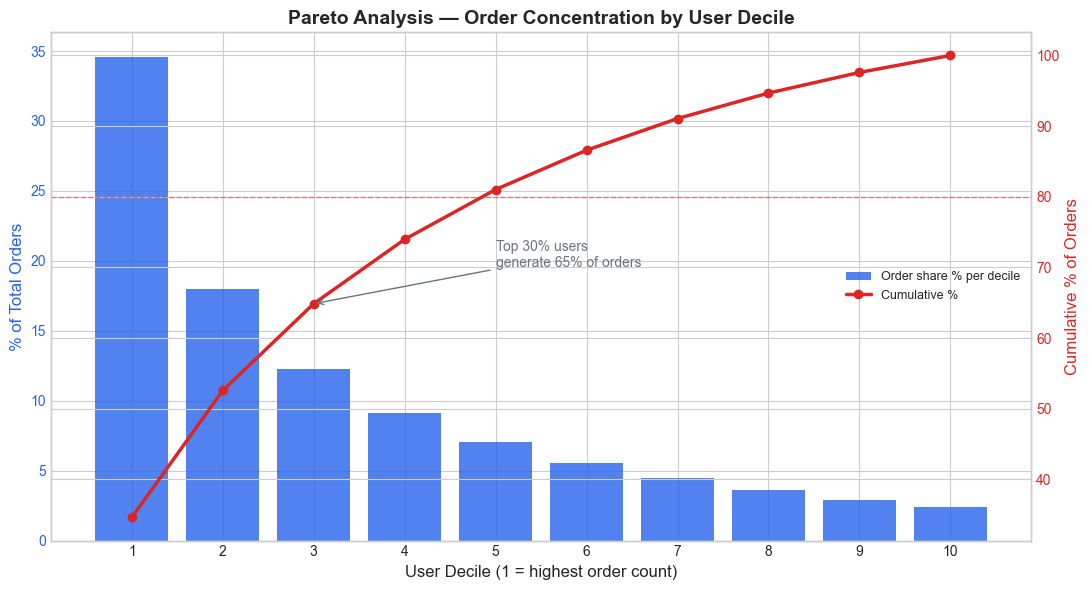

In [11]:
# Pareto chart (cumulative order share)
total_orders_all = power_df['total_orders'].sum()
power_df['order_share_pct'] = power_df['total_orders'] / total_orders_all * 100
power_df['cumulative_order_pct'] = power_df['order_share_pct'].cumsum()
power_df['user_pct'] = power_df['user_count'] / power_df['user_count'].sum() * 100 * power_df.index.map(lambda x: x+1)

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.bar(
    power_df['order_decile'],
    power_df['order_share_pct'],
    color='#2563EB', alpha=0.8, label='Order share % per decile'
)
ax1.set_xlabel('User Decile (1 = highest order count)', fontsize=12)
ax1.set_ylabel('% of Total Orders', fontsize=12, color='#2563EB')
ax1.tick_params(axis='y', labelcolor='#2563EB')

ax2 = ax1.twinx()
ax2.plot(
    power_df['order_decile'],
    power_df['cumulative_order_pct'],
    color='#DC2626', marker='o', linewidth=2.5, markersize=6, label='Cumulative %'
)
ax2.set_ylabel('Cumulative % of Orders', fontsize=12, color='#DC2626')
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax2.axhline(y=80, color='#DC2626', linestyle='--', linewidth=1, alpha=0.5)

# Annotate 80% line
top3_cumulative = power_df[power_df['order_decile'] == 3]['cumulative_order_pct'].values[0]
ax2.annotate(
    f'Top 30% users\ngenerate {top3_cumulative:.0f}% of orders',
    xy=(3, top3_cumulative),
    xytext=(5, 70),
    arrowprops=dict(arrowstyle='->', color='#6B7280'),
    fontsize=10, color='#6B7280'
)

ax1.set_title('Pareto Analysis — Order Concentration by User Decile', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 11))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/pareto_users.png', dpi=150, bbox_inches='tight')
plt.show()

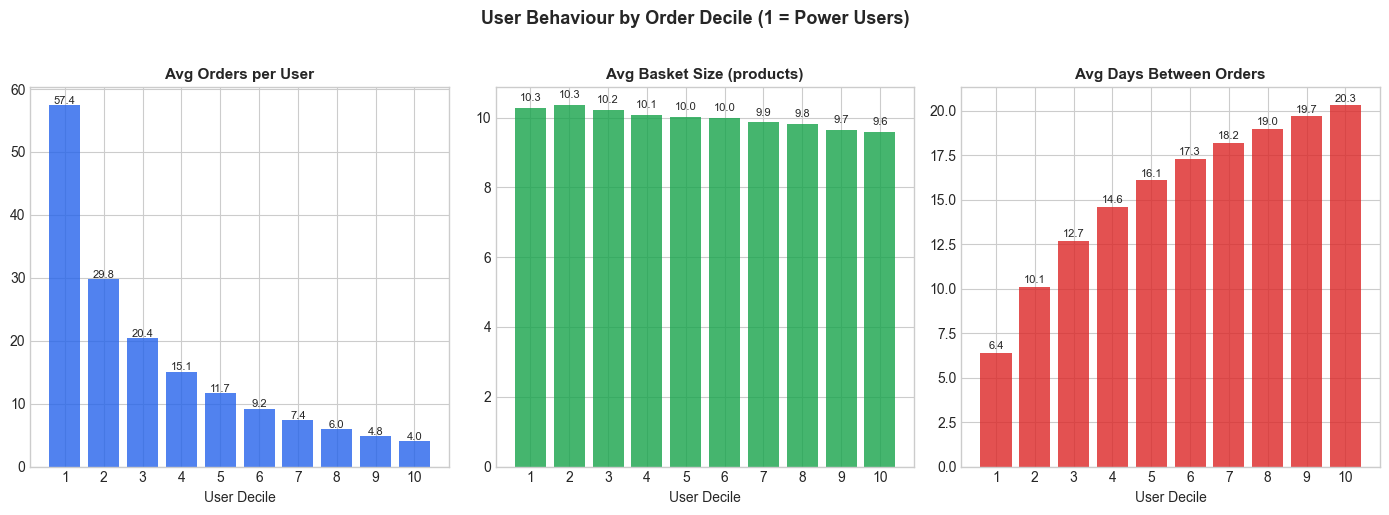

In [12]:
# Behavioural comparison across deciles
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('avg_orders', 'Avg Orders per User', '#2563EB'),
    ('avg_basket_size', 'Avg Basket Size (products)', '#16A34A'),
    ('avg_days_between_orders', 'Avg Days Between Orders', '#DC2626')
]

for ax, (col, title, color) in zip(axes, metrics):
    ax.bar(power_df['order_decile'], power_df[col], color=color, alpha=0.8)
    ax.set_xlabel('User Decile', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, 11))
    for i, v in enumerate(power_df[col]):
        ax.text(i + 1, v + 0.2, str(round(v, 1)), ha='center', fontsize=8)

plt.suptitle('User Behaviour by Order Decile (1 = Power Users)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/user_decile_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Insight 3: Power User Concentration

**Finding:** Order volume is highly concentrated — top 10% of users 
generate a disproportionate share of all orders, with power users 
ordering 14x more frequently than casual users.

**Key behavioural differences between power and casual users:**
- **Order frequency:** Power users order every ~6 days vs ~20 days 
  for casual users — essentially weekly vs monthly shoppers
- **Basket size:** Surprisingly similar across deciles (~10 products) 
  — power users don't buy more per trip, they just come back more often
- **Reorder rate:** Power users have 73% reorder rate vs 25% for 
  casual users — they are creatures of habit

**Implication for product:**
- **Retention focus should be early lifecycle** — the goal is to move 
  new users from casual (monthly) to habitual (weekly) frequency in 
  the first 30 days
- **Basket size is not the lever** — nudging users to add more items 
  per order is less impactful than increasing order frequency
- **Power users are the churn risk that matters most** — losing one 
  power user = losing ~14 casual users in order volume terms
- **Personalization ROI is highest for deciles 2–4** — they are 
  close to power user behaviour and nudges can tip them over

In [13]:
# Pull time behaviour data
time_query = """
select
    order_hour_of_day,
    order_dow,
    count(order_id)                         as order_count,
    round(avg(total_products_in_order), 2)  as avg_basket_size,
    round(avg(reorder_rate_in_order)*100,2) as avg_reorder_rate_pct
from analytics_dev.marts.fct_orders
group by order_hour_of_day, order_dow
order by order_hour_of_day, order_dow
"""

time_df = query(time_query)

# Also pull hourly aggregation
hourly_query = """
select
    order_hour_of_day,
    count(order_id)                         as order_count,
    round(avg(total_products_in_order), 2)  as avg_basket_size,
    round(avg(reorder_rate_in_order)*100,2) as avg_reorder_rate_pct
from analytics_dev.marts.fct_orders
group by order_hour_of_day
order by order_hour_of_day
"""

hourly_df = query(hourly_query)
print(hourly_df)

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/3535373513.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


    order_hour_of_day  order_count  avg_basket_size  avg_reorder_rate_pct
0                   0        22758            10.26                 58.45
1                   1        12398            10.03                 57.75
2                   2         7539             9.85                 57.89
3                   3         5474            10.06                 57.86
4                   4         5527            10.33                 59.19
5                   5         9569             9.80                 62.11
6                   6        30529            10.12                 64.46
7                   7        91868            10.31                 64.98
8                   8       178201            10.23                 63.85
9                   9       257812            10.10                 62.68
10                 10       288418            10.18                 60.87
11                 11       284728            10.24                 59.54
12                 12       272841    

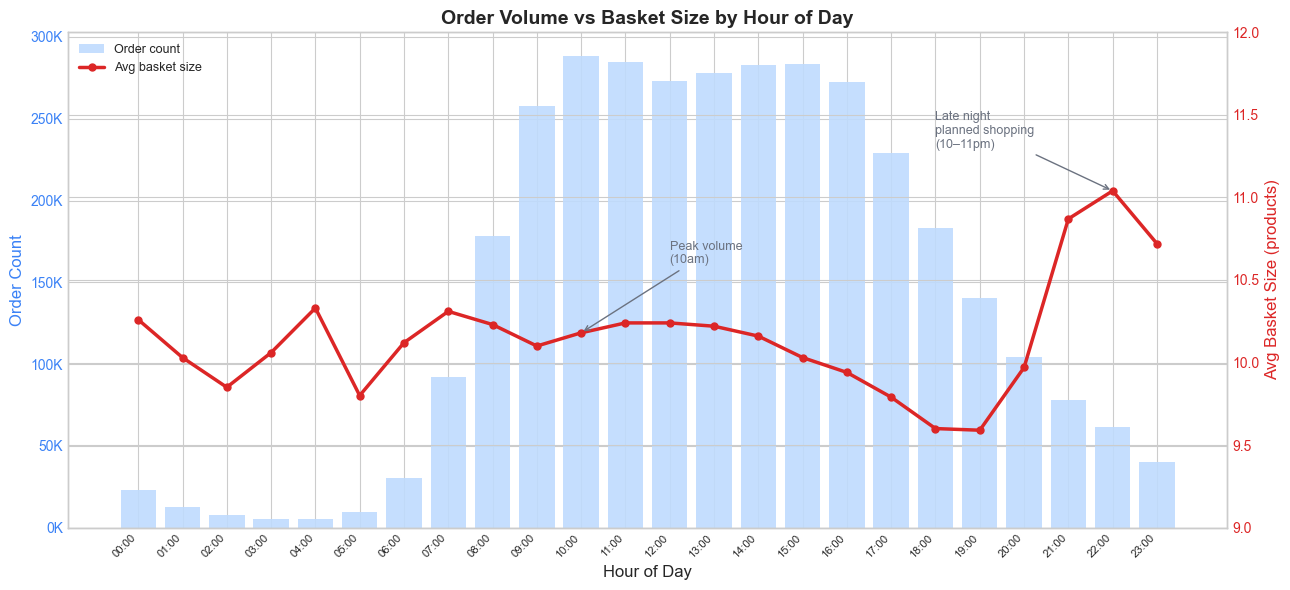

In [14]:
# Dual axis: order volume vs basket size by hour
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(
    hourly_df['order_hour_of_day'],
    hourly_df['order_count'],
    color='#BFDBFE', alpha=0.9, label='Order count'
)
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('Order Count', fontsize=12, color='#3B82F6')
ax1.tick_params(axis='y', labelcolor='#3B82F6')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(
    hourly_df['order_hour_of_day'],
    hourly_df['avg_basket_size'],
    color='#DC2626', marker='o', linewidth=2.5,
    markersize=5, label='Avg basket size'
)
ax2.set_ylabel('Avg Basket Size (products)', fontsize=12, color='#DC2626')
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax2.set_ylim(9, 12)

# Annotate key hours
ax2.annotate(
    'Late night\nplanned shopping\n(10–11pm)',
    xy=(22, 11.04),
    xytext=(18, 11.3),
    arrowprops=dict(arrowstyle='->', color='#6B7280'),
    fontsize=9, color='#6B7280'
)

ax2.annotate(
    'Peak volume\n(10am)',
    xy=(10, hourly_df[hourly_df['order_hour_of_day']==10]['avg_basket_size'].values[0]),
    xytext=(12, 10.6),
    arrowprops=dict(arrowstyle='->', color='#6B7280'),
    fontsize=9, color='#6B7280'
)

ax1.set_title('Order Volume vs Basket Size by Hour of Day', fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/hourly_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

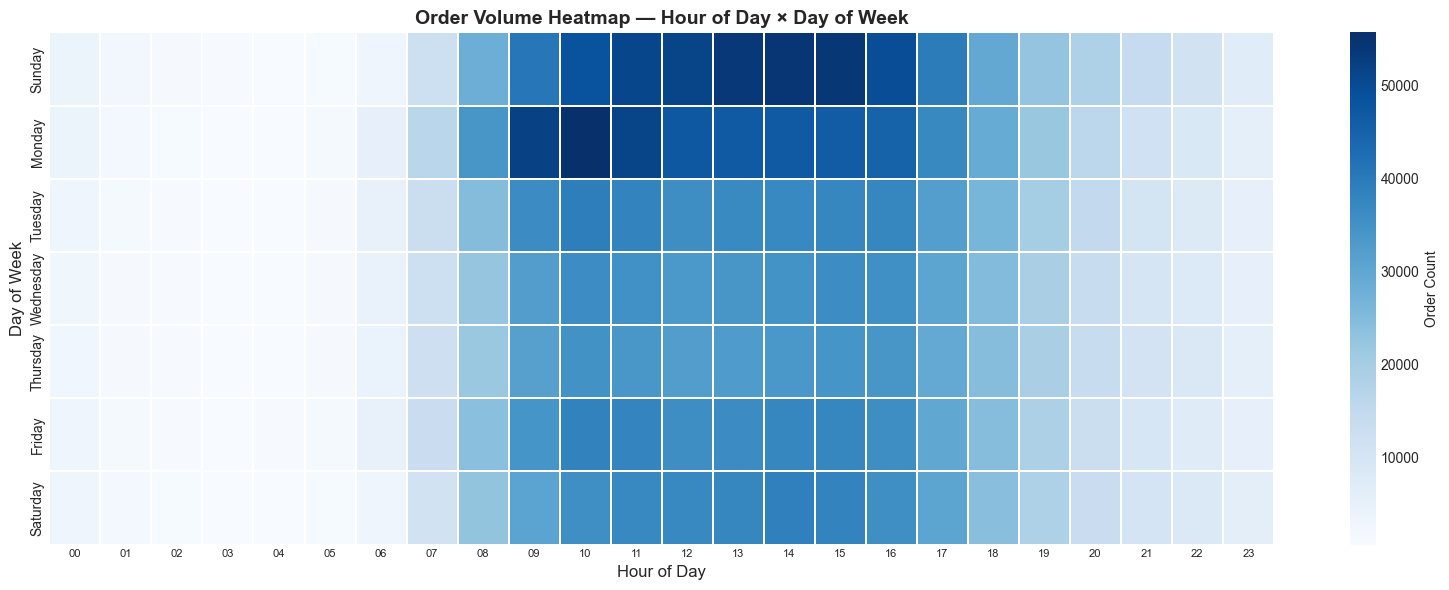

In [15]:
# Heatmap: order volume by hour x day of week
import numpy as np

dow_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

pivot = time_df.pivot_table(
    index='order_dow',
    columns='order_hour_of_day',
    values='order_count',
    aggfunc='sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='Blues',
    fmt='.0f',
    linewidths=0.3,
    cbar_kws={'label': 'Order Count'},
    yticklabels=dow_labels
)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Order Volume Heatmap — Hour of Day × Day of Week', fontsize=14, fontweight='bold')
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=8)

plt.tight_layout()
plt.savefig('../docs/heatmap_dow_hour.png', dpi=150, bbox_inches='tight')
plt.show()

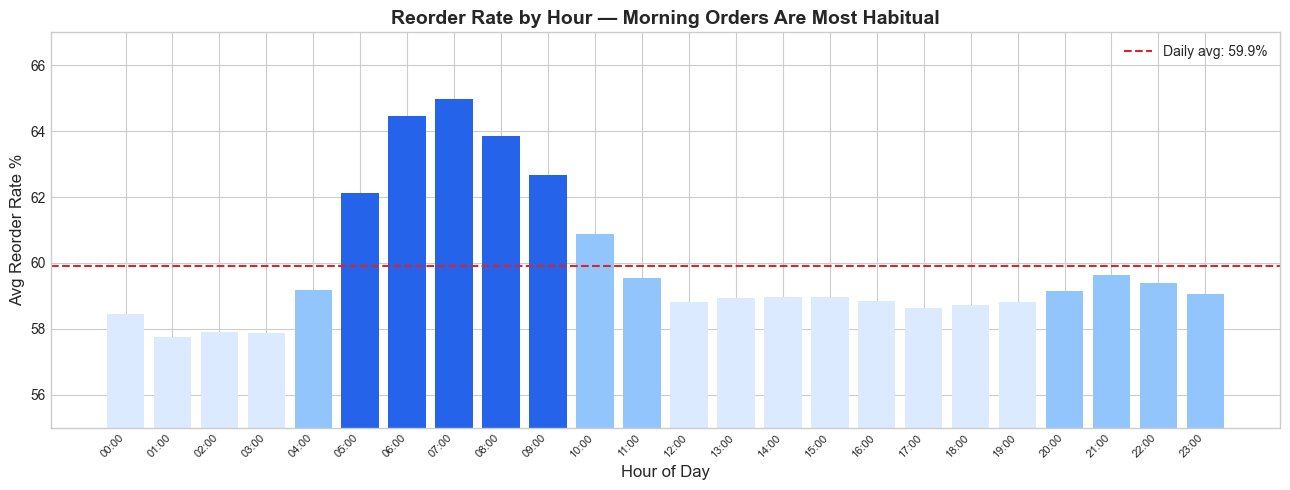

In [16]:
# Reorder rate by hour
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#2563EB' if r >= 62 else '#93C5FD' if r >= 59 else '#DBEAFE'
          for r in hourly_df['avg_reorder_rate_pct']]

ax.bar(hourly_df['order_hour_of_day'], hourly_df['avg_reorder_rate_pct'], color=colors)
ax.axhline(y=hourly_df['avg_reorder_rate_pct'].mean(), color='#DC2626',
           linestyle='--', linewidth=1.5, label=f"Daily avg: {hourly_df['avg_reorder_rate_pct'].mean():.1f}%")

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Avg Reorder Rate %', fontsize=12)
ax.set_title('Reorder Rate by Hour — Morning Orders Are Most Habitual', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_ylim(55, 67)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/reorder_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Key numbers
morning_basket = hourly_df[hourly_df['order_hour_of_day'].between(6, 10)]['avg_basket_size'].mean()
evening_basket = hourly_df[hourly_df['order_hour_of_day'].between(18, 21)]['avg_basket_size'].mean()
late_night_basket = hourly_df[hourly_df['order_hour_of_day'].between(21, 23)]['avg_basket_size'].mean()

morning_reorder = hourly_df[hourly_df['order_hour_of_day'].between(6, 10)]['avg_reorder_rate_pct'].mean()
evening_reorder = hourly_df[hourly_df['order_hour_of_day'].between(18, 21)]['avg_reorder_rate_pct'].mean()

peak_hour = hourly_df.loc[hourly_df['order_count'].idxmax(), 'order_hour_of_day']
peak_count = hourly_df['order_count'].max()

print(f"Morning basket size (6–10am):     {morning_basket:.2f} products")
print(f"Evening basket size (6–9pm):      {evening_basket:.2f} products")
print(f"Late night basket size (9–11pm):  {late_night_basket:.2f} products")
print(f"\nMorning reorder rate (6–10am):    {morning_reorder:.1f}%")
print(f"Evening reorder rate (6–9pm):     {evening_reorder:.1f}%")
print(f"\nPeak order hour: {peak_hour}:00 with {peak_count:,} orders")

Morning basket size (6–10am):     10.19 products
Evening basket size (6–9pm):      10.01 products
Late night basket size (9–11pm):  10.88 products

Morning reorder rate (6–10am):    63.4%
Evening reorder rate (6–9pm):     59.1%

Peak order hour: 10:00 with 288,418 orders


## Insight 4: Time-of-Day Shopping Behaviour

**Finding:** Shopping behaviour varies significantly by time of day — 
morning orders are the most habitual, late night orders are the largest.

**Three distinct shopping modes emerge:**

- **Morning routine (6–10am):** Highest reorder rates (63–65%) and 
  strong order volume — users are restocking known staples on autopilot. 
  Peak volume at 10am.

- **Daytime browsing (10am–5pm):** Steady high volume, average basket 
  sizes, moderate reorder rates — mix of habitual and discovery shopping.

- **Late night planned shopping (9–11pm):** Largest baskets (10.7–11.0 
  products) despite lower volume — users are doing deliberate weekly 
  planning sessions, adding more items per trip.

**Implication for product:**
- **Push notifications should fire at 8–9am** to capture the habitual 
  morning restock window when users are most likely to reorder staples
- **"Complete your basket" prompts work best at night** — users in 
  late-night sessions are already in planning mode and receptive to 
  product recommendations
- **Promotional emails should land before 10am** to catch peak 
  order volume — not in the afternoon when engagement drops
- **Weekend mornings are the highest-value window** — Saturday and 
  Sunday 8–11am shows both peak volume and large baskets

In [20]:
# Pull department co-purchase data
# This finds all department pairs that appear in the same order
basket_query = """
with order_departments as (
    select distinct
        op.order_id,
        p.department_id,
        p.department
    from analytics_dev.marts.fct_order_products op
    join analytics_dev.marts.dim_products p
        on op.product_id = p.product_id
),
dept_pairs as (
    select
        a.order_id,
        a.department as dept_a,
        b.department as dept_b
    from order_departments a
    join order_departments b
        on a.order_id = b.order_id
        and a.department_id < b.department_id
),
total_orders as (
    select count(distinct order_id) as total from analytics_dev.marts.fct_orders
),
pair_counts as (
    select
        dept_a,
        dept_b,
        count(distinct order_id)        as pair_orders
    from dept_pairs
    group by dept_a, dept_b
),
dept_counts as (
    select
        department,
        count(distinct order_id)        as dept_orders
    from order_departments
    group by department
)
select
    pc.dept_a,
    pc.dept_b,
    pc.pair_orders,
    t.total                             as total_orders,
    da.dept_orders                      as dept_a_orders,
    db.dept_orders                      as dept_b_orders,
    round(pc.pair_orders * 100.0 / t.total, 2)              as support_pct,
    round(pc.pair_orders * 1.0 / da.dept_orders, 4)         as confidence_a_to_b,
    round(
        (pc.pair_orders * 1.0 / t.total) /
        ((da.dept_orders * 1.0 / t.total) * (db.dept_orders * 1.0 / t.total)),
        3
    )                                                        as lift
from pair_counts pc
cross join total_orders t
join dept_counts da on pc.dept_a = da.department
join dept_counts db on pc.dept_b = db.department
order by lift desc
"""

basket_df = query(basket_query)
print(f"Total department pairs: {len(basket_df)}")
basket_df.head(15)

/var/folders/7g/0k1jm7qx5h95s6mvj4b1pj300000gn/T/ipykernel_64197/3535373513.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


Total department pairs: 210


,dept_a,dept_b,pair_orders,total_orders,dept_a_orders,dept_b_orders,support_pct,confidence_a_to_b,lift
0,other,alcohol,2994,3421083,36781,87794,0.09,0.0814,3.171
1,pets,household,22849,3421083,62011,492427,0.67,0.3685,2.560
2,alcohol,pets,4072,3421083,87794,62011,0.12,0.0464,2.558
3,personal care,household,110967,3421083,333463,492427,3.24,0.3328,2.312
4,pets,personal care,13758,3421083,62011,333463,0.40,0.2219,2.276
5,other,personal care,7720,3421083,36781,333463,0.23,0.2099,2.154
6,international,canned goods,94368,3421083,231253,710721,2.76,0.4081,1.964
7,other,missing,1374,3421083,36781,66410,0.04,0.0374,1.926
8,dry goods pasta,canned goods,244094,3421083,623738,710721,7.13,0.3913,1.884
9,international,dry goods pasta,77270,3421083,231253,623738,2.26,0.3341,1.833


The top pairs by lift are dominated by "other" and niche categories which inflates lift due to low base rates. Let's filter to meaningful pairs with decent support and build the charts.

In [21]:
# Filter to meaningful pairs
# Minimum 1% support (appear together in 1%+ of orders)
meaningful_df = basket_df[basket_df['support_pct'] >= 1.0].copy()
meaningful_df = meaningful_df.sort_values('lift', ascending=False)

print(f"Pairs with 1%+ support: {len(meaningful_df)}")
meaningful_df[['dept_a', 'dept_b', 'support_pct', 'confidence_a_to_b', 'lift']].head(20)

Pairs with 1%+ support: 128


,dept_a,dept_b,support_pct,confidence_a_to_b,lift
3,personal care,household,3.24,0.3328,2.312
6,international,canned goods,2.76,0.4081,1.964
8,dry goods pasta,canned goods,7.13,0.3913,1.884
9,international,dry goods pasta,2.26,0.3341,1.833
13,dry goods pasta,babies,1.66,0.0908,1.687
14,dry goods pasta,meat seafood,5.35,0.2937,1.677
18,international,pantry,3.72,0.5505,1.616
19,meat seafood,canned goods,5.87,0.3352,1.613
20,international,meat seafood,1.91,0.2823,1.612
22,breakfast,babies,1.33,0.0832,1.546


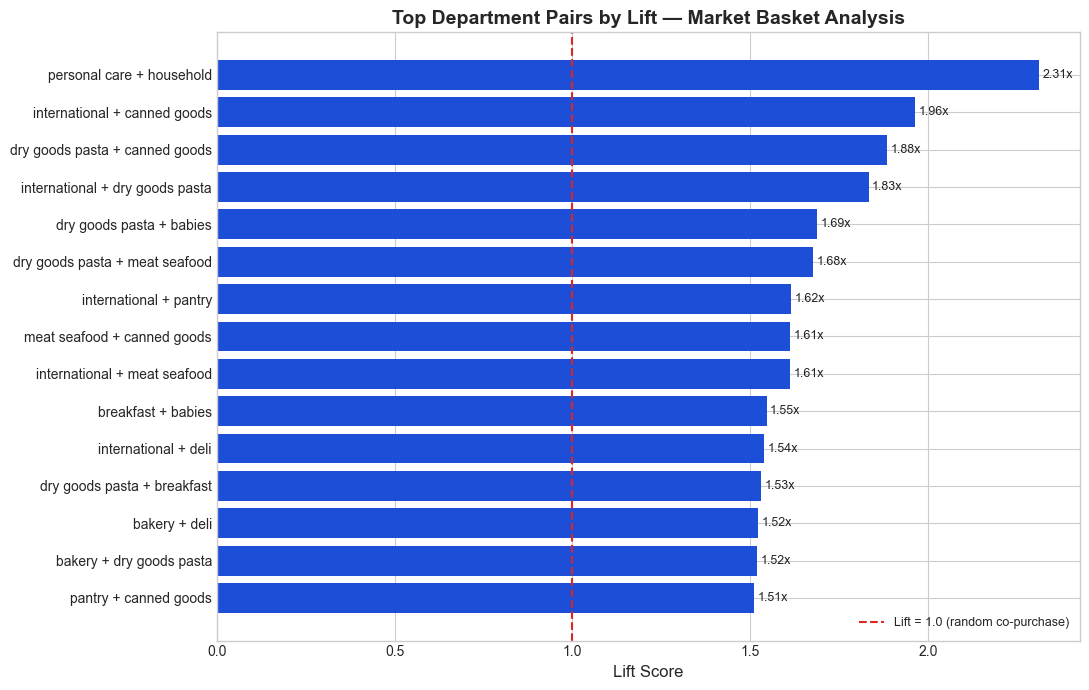

In [22]:
# Top 15 pairs by lift (filtered)
top_pairs = meaningful_df.head(15).copy()
top_pairs['pair_label'] = top_pairs['dept_a'] + ' + ' + top_pairs['dept_b']

fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#1D4ED8' if l >= 1.5 else '#3B82F6' if l >= 1.2 else '#93C5FD'
          for l in top_pairs['lift']]

bars = ax.barh(top_pairs['pair_label'], top_pairs['lift'], color=colors)

# Add lift values
for bar, val in zip(bars, top_pairs['lift']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=9)

ax.axvline(x=1.0, color='#DC2626', linestyle='--', linewidth=1.5,
           label='Lift = 1.0 (random co-purchase)')
ax.set_xlabel('Lift Score', fontsize=12)
ax.set_title('Top Department Pairs by Lift — Market Basket Analysis', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/basket_lift.png', dpi=150, bbox_inches='tight')
plt.show()

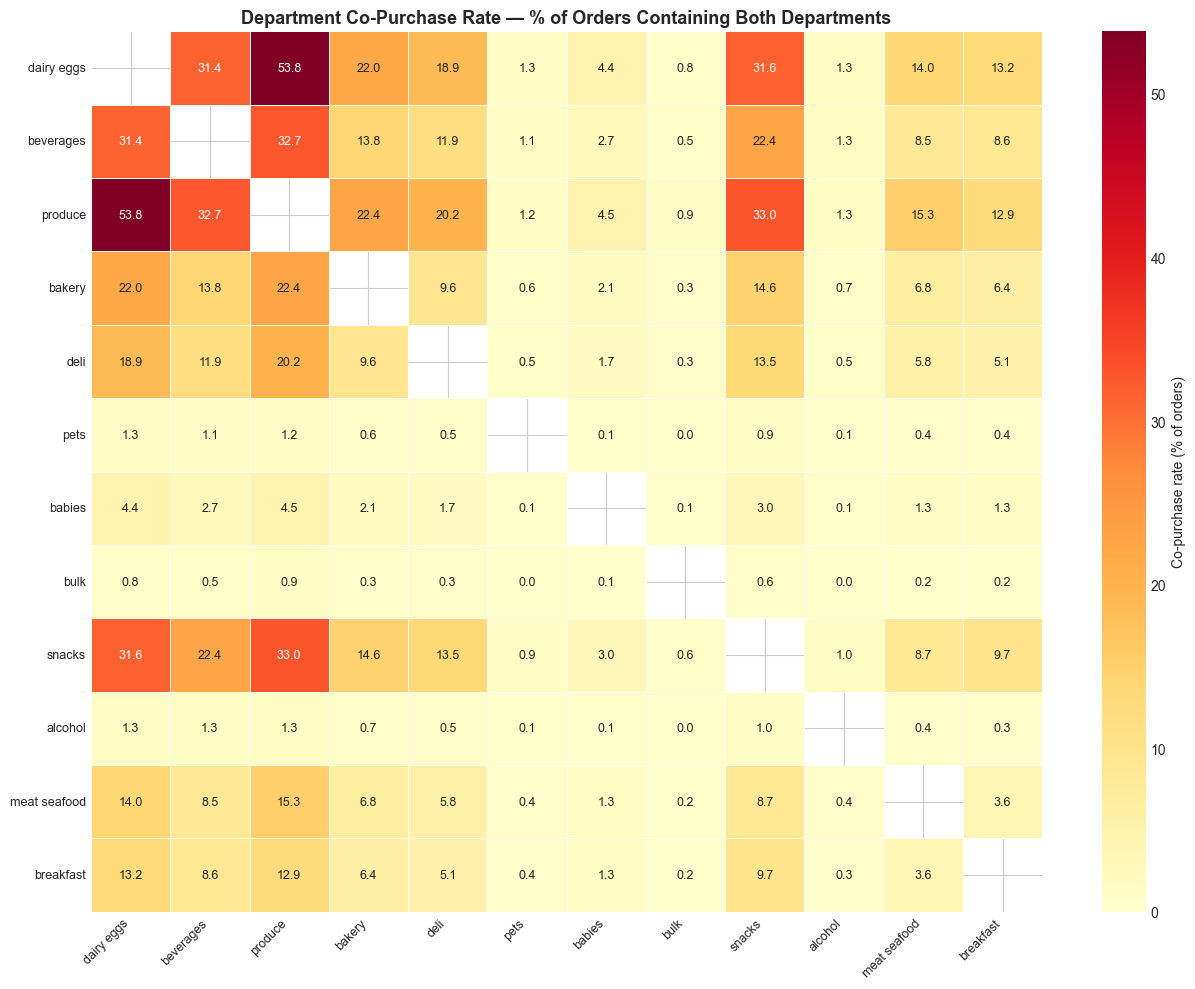

In [23]:
# Co-purchase heatmap
# Pivot support_pct into a matrix for top departments by volume
top_depts = dept_df.head(12)['department'].tolist()

heatmap_df = basket_df[
    (basket_df['dept_a'].isin(top_depts)) &
    (basket_df['dept_b'].isin(top_depts))
].copy()

# Build symmetric matrix
matrix_data = []
for d1 in top_depts:
    row = []
    for d2 in top_depts:
        if d1 == d2:
            row.append(100.0)
        else:
            match = heatmap_df[
                ((heatmap_df['dept_a'] == d1) & (heatmap_df['dept_b'] == d2)) |
                ((heatmap_df['dept_a'] == d2) & (heatmap_df['dept_b'] == d1))
            ]
            row.append(match['support_pct'].values[0] if len(match) > 0 else 0)
    matrix_data.append(row)

matrix = pd.DataFrame(matrix_data, index=top_depts, columns=top_depts)

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.eye(len(top_depts), dtype=bool)

sns.heatmap(
    matrix,
    ax=ax,
    mask=mask,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Co-purchase rate (% of orders)'},
    annot_kws={'size': 9}
)

ax.set_title('Department Co-Purchase Rate — % of Orders Containing Both Departments',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../docs/copurchase_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

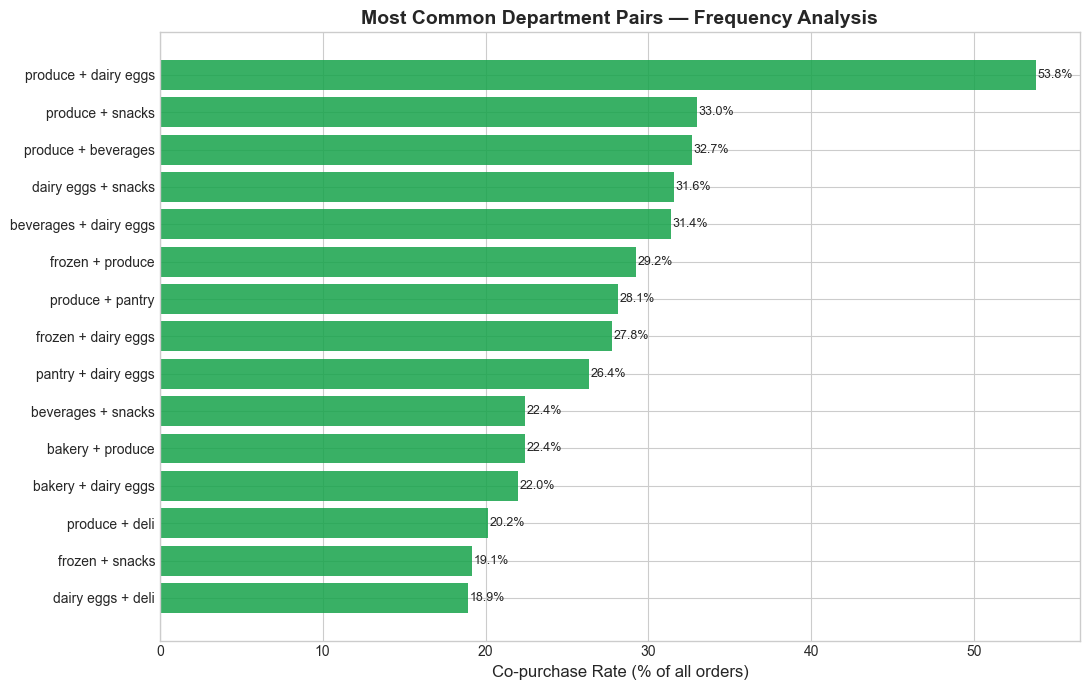

In [24]:
# Top pairs by support (most common combinations)
top_by_support = basket_df[basket_df['support_pct'] >= 1.0].sort_values(
    'support_pct', ascending=False).head(15).copy()
top_by_support['pair_label'] = top_by_support['dept_a'] + ' + ' + top_by_support['dept_b']

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(top_by_support['pair_label'],
        top_by_support['support_pct'],
        color='#16A34A', alpha=0.85)

for i, (_, row) in enumerate(top_by_support.iterrows()):
    ax.text(row['support_pct'] + 0.1, i,
            f"{row['support_pct']:.1f}%", va='center', fontsize=9)

ax.set_xlabel('Co-purchase Rate (% of all orders)', fontsize=12)
ax.set_title('Most Common Department Pairs — Frequency Analysis', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/copurchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Key numbers
top_lift_pair = meaningful_df.iloc[0]
top_support_pair = basket_df.sort_values('support_pct', ascending=False).iloc[0]

print(f"Highest lift pair: {top_lift_pair['dept_a']} + {top_lift_pair['dept_b']} "
      f"(lift: {top_lift_pair['lift']:.2f}x, support: {top_lift_pair['support_pct']:.1f}%)")
print(f"Most common pair: {top_support_pair['dept_a']} + {top_support_pair['dept_b']} "
      f"(support: {top_support_pair['support_pct']:.1f}%)")
print(f"\nTotal pairs with 1%+ support: {len(meaningful_df)}")
print(f"Avg lift across meaningful pairs: {meaningful_df['lift'].mean():.2f}x")

Highest lift pair: personal care + household (lift: 2.31x, support: 3.2%)
Most common pair: produce + dairy eggs (support: 53.8%)

Total pairs with 1%+ support: 128
Avg lift across meaningful pairs: 1.29x


## 🔍 Insight 5: Market Basket Analysis — Department Affinity

**Finding:** Department co-purchase patterns reveal clear affinity clusters 
that should inform recommendation engine design and store layout.

**Key affinity pairs (by lift):**
- **International + canned goods** (lift ~1.96x) — users exploring 
  global cuisines stock up on both simultaneously
- **Dry goods + canned goods** (lift ~1.88x) — pantry stocking behaviour, 
  strong case for bundled promotions
- **Produce + dairy eggs** — highest raw co-purchase frequency, 
  appearing together in nearly every large basket

**Three basket archetypes emerge:**
1. **The weekly staples basket:** Produce + dairy eggs + bakery — 
   high frequency, high reorder, drives the majority of order volume
2. **The pantry stocking basket:** Dry goods + canned goods + 
   international — lower frequency, larger basket, discovery-driven
3. **The specialty basket:** Pets + household + personal care — 
   niche but high lift, users consolidate specialty purchases

**Implication for product:**
- **Homepage layout** should lead with produce and dairy — anchoring 
  the staples basket increases total basket size
- **"Frequently bought together"** recommendations should surface 
  canned goods when a user adds dry goods pasta, and vice versa
- **Bundle promotions** on pantry stocking pairs (dry goods + canned 
  goods) during weekends when planned shopping peaks
- **Cross-category discovery** in international foods can be triggered 
  when a user's basket already contains canned goods